In [1]:
import os
# os.environ["TORCH_USE_CUDA_DSA"] = "1"
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import numpy as np
from numpy.random import default_rng
from time import perf_counter
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import TwoSlopeNorm, Normalize
import torch

from EqLearner import EqLearner1D
from func_libraries import Poly_Deriv_Library
from sparse_regress_algs import SparseRegressAlg, RFE, Cross_Val_RFE, Cross_Val_RFE_V2, SSR
from data_sampling import Rand_Col_Sampler
from PinnSrPlusPlusComparisonSettings import DefaultEQsModelParameters, OptimizedEQsModelParameters 
from data_loaders import PDELearningMatDataVerB, PDELearningMatData
import Networks
# from PinnSrPlusEqSolutions import OneDimSols
from OneDimSols import OneDimSols

### Which Data Set to Load up from saved models

In [2]:
# # KdV
# jobId = 20922
# arrayId = 23
# dflag = 13
# ver = 2

# # Allen Cahn
# jobId = 20645
# arrayId = 10
# dflag = 3
# ver = 1

# Allen Cahn
jobId = 20723
arrayId = 20
dflag = 3
ver = 3

# # Kln-Grd
# jobId = 20801
# arrayId = 3
# dflag = 14
# ver = 2

# # Heat EQ
# jobId = 20606
# arrayId = 5
# dflag = 9
# ver = 1

# # Burgres Exp EQ
# jobId = 20411
# arrayId = 33
# dflag = 6
# ver = 1

# # Dynamic Beam EQ
# jobId = 20891
# arrayId = 33
# dflag = 15
# ver = 1


data_slct_type = "RandPointsData"
node = 'desktop'

In [3]:
jobID , jobVer = jobId, arrayId
dvc = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
(Dname, nDpnts, nTrn, nCpnts, noise, data_seed, sptl_ord, tmp_order, polyDeg, 
    numLyrsU, nPrLU, prd_stuff, four_stuff, rnd_wght_fct,
    ADO_iters, Kfolds, ADO_alphas, 
    min_epchs, max_epchs, lrn_rt, preAlpha, preGamma,
    min_pst_epchs, max_pst_epchs, pst_alpha, pst_lrn_rt) = OptimizedEQsModelParameters(dFlag=dflag, ver=ver, run=jobVer, data_type=data_slct_type, computer=node)

Kfolds = 20
# Kfolds = 40
    
slvr = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=ADO_iters, thrshld_val=1e-8)

DataFile = '../Testing_DataSets/'+Dname+'.mat'
data_set = (Dname + "_" + "N" + str(int(noise)) + "_" +
                "P" + str(nDpnts))

sv_mdl_name = 'OptimalVer4LrnrForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)
    
(d_seed, Nsp, Ns, subsample_prcntg,
            X_trn, U_trn,
            X_tst, U_tst,
            bounds) = PDELearningMatDataVerB(fname=DataFile, Sptldims=1, Ntrn=nDpnts, Ntst=nDpnts//4, noisePrcntg=noise, 
                 seed=data_seed, to_float=True,)

data = sio.loadmat(file_name=DataFile)
x = data['x'].flatten()
t = data['t'].flatten()
u = data['usol']

noisePrcntg = noise if noise<1.0 else noise/100

rng = default_rng(seed=data_seed)
sol = u + rng.normal(loc=0, scale=noisePrcntg*np.std(u) , size=u.shape)

n_x = x.shape[0]
n_t = t.shape[0]

[X, T] = np.meshgrid(x, t)
if sol.shape!=X.shape:
    sol = sol.T
    u = u.T

pts = np.concatenate((X.reshape((-1,1),order='C'), T.reshape((-1,1),order='C')), axis=1)
nsy_vals = sol.reshape((-1,1), order='C')
cln_vals = u.reshape((-1,1), order='C')



res_dict = {'jobID':jobID, 'jobVer':jobVer, 'node':node, 'subsample_prcntg':subsample_prcntg, 'noisePrcntg':noise, 'NpSeed':d_seed, 'Ns':Ns}

libr = Poly_Deriv_Library(
        poly_degree=polyDeg,
        include_poly_interaction=True,
        poly_interaction_only=False,
        derivative_order=sptl_ord,
        sptl_dims=1,
        include_bias=False,
        include_deriv_interaction=True,
        multi_indices=None,
        device=dvc,
        data_type=torch.float32)

d_dict = {"Train_Inputs":X_trn, "Train_Targets":U_trn, "Test_Inputs":X_tst, "Test_Targets":U_tst}

col_smplr = Rand_Col_Sampler(sampler='halton', 
                             dims=2, seed=None, 
                             bounds=bounds, requires_grad=True, 
                             device=dvc, data_type=torch.float32)

if prd_stuff or four_stuff or rnd_wght_fct:
    net = Networks.MLP(in_dim=2, num_layers=numLyrsU, hid_dim=nPrLU,out_dim=1,
                      activ_func=torch.nn.Tanh(),
                      prd_stuff=prd_stuff, four_stuff=four_stuff,
                      rnd_wght_fct=rnd_wght_fct).to(device=dvc)

else:
    net = torch.nn.Sequential(
            torch.nn.Linear(in_features=2, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=1, bias=True)
    ).to(device=dvc, dtype=torch.float32)

    # # for param in net.parameters():
    # #     if param.ndim==2:
    # #         torch.nn.init.xavier_normal_(param, gain=1.41)
    # #     elif param.ndim==1:
    # #         torch.nn.init.zeros_(param)

    for name, param in net.named_parameters(): 
        if 'weight'in name:
            torch.nn.init.xavier_normal_(param.data, gain=1.41)
        # if 'bias' in name:
        #     torch.nn.init.zeros_(param.data)
    
libr.fit(network=net, inpts=torch.rand(size=(2,2), device=dvc, dtype=torch.float32))
lib_names = libr.get_library_names(net_out_func_names=['u'])

init_lmbda = torch.zeros(size=(len(lib_names),1), device=dvc,)

The entropy or np seed used for seeding the default rng routine is 322746179365621550482400009727175656067


C:\Users\urzua\AppData\Local\Temp\ipykernel_47644\3798166854.py:23: UserWarning: WARNING; Given float noisePrcntg value is either is greater than 1.0 and so to convert it to
a decimal value it will be divided by 100 as we are interpretting any value greater than 1.0
to be a percentage and thus to convert out of a percentage (i.e p%) divided by 100 and use 
that value (i.e p/100).
  bounds) = PDELearningMatDataVerB(fname=DataFile, Sptldims=1, Ntrn=nDpnts, Ntst=nDpnts//4, noisePrcntg=noise,


In [4]:
folder_loc = "Saved_Models/"+data_set
path = folder_loc +'/'+sv_mdl_name+'.tar'
state = torch.load(f=path, weights_only=False)

net.load_state_dict(state['net_state_dict'])

<All keys matched successfully>

In [5]:
if prd_stuff or four_stuff or rnd_wght_fct:
    net2 = Networks.MLP(in_dim=2, num_layers=numLyrsU, hid_dim=nPrLU,out_dim=1,
                      activ_func=torch.nn.Tanh(),
                      prd_stuff=prd_stuff, four_stuff=four_stuff,
                      rnd_wght_fct=rnd_wght_fct).to(device=dvc)

else:
    net2 = torch.nn.Sequential(
            torch.nn.Linear(in_features=2, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            torch.nn.Linear(in_features=nPrLU, out_features=1, bias=True)
    ).to(device=dvc, dtype=torch.float32)

    # # for param in net2.parameters():
    # #     if param.ndim==2:
    # #         torch.nn.init.xavier_normal_(param, gain=1.41)
    # #     elif param.ndim==1:
    # #         torch.nn.init.zeros_(param)

    for name, param in net2.named_parameters(): 
        if 'weight'in name:
            torch.nn.init.xavier_normal_(param.data, gain=1.41)
        # if 'bias' in name:
        #     torch.nn.init.zeros_(param.data)

In [6]:
lrnr = EqLearner1D(net=net2,
            Lmbda=init_lmbda.requires_grad_(True),
            lib_func=libr,
            sprs_slvr=slvr,
            data_dict=d_dict,
            tmprl_ords=[tmp_order],
            col_pnts_smplr=col_smplr,
            N_col_pnts=nCpnts,
            ntwk_out_names=["u"],
            device=dvc,
            data_type=torch.float32
)

In [7]:
err, errs, RHS_eq, = OneDimSols(dataset=Dname.replace("%2A", "*"), lib=lib_names, lrnd_sol=torch.from_numpy(state['lambda']))
learned = lrnr.Learned_EQ(coefs=torch.from_numpy(state['lambda']),output=False, sup_zeros=True,)
print("The learned equation(s) was ...\n" + learned)
crctEQ = 'u_'+'t'*tmp_order +' = '  + RHS_eq
fig_title = 'Learned EQ - '+learned+'\n Correct EQ - '+crctEQ

# lrnr.WriteResults(data_set_name=data_set, file_name=data_set+"OptimalVer4", precision=5, true_eq=crctEQ, errors=[err, errs], act_func='Tanh()', **res_dict)
# lrnr.TrainingLossPlots(dataset_name=data_set, file_name=saveName, plot_title=fig_title,)
# lrnr.ContourLikeComparisonPlot(dataset_name=data_set, pts=pts, values=U, fig_title=fig_title, state="PostTrained", show_fig=False, save_fig=True, save_title=saveName+'PostTrained', dif=False, exact=False, learned=False)
# lrnr.Loss_Score_Complexity_Plot(dataset_name=data_set, save_dir_name=saveName, save_figs=True)

# lrnr.AnimatedPlot(dataset_name=data_set, spdx=2.0, pts=pts, values=U, 
#                      ani_title=saveName+'PostTrained', fig_title=fig_title, )

The learned equation(s) was ...
u_t = 8.80509440e-01*u + 3.34918000e-03*u_x0x0 + -8.50377020e-01*(u)^3 


### Random Time Stamp of the learned, noisy and exact data

In [8]:
lrn_vals = net(torch.from_numpy(pts).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()

In [9]:
dgt = 3
rnd = int(np.log10(np.min(t[1:]-t[:-1]))) + 3
y_max = np.max([np.ceil(cln_vals.max()),np.ceil(nsy_vals.max()), np.ceil(lrn_vals.max()) ])
y_min = np.min([np.floor(cln_vals.min()),np.floor(nsy_vals.min()), np.floor(lrn_vals.min()) ])
x_max, x_min = np.ceil(pts[:, 0].max()), np.floor(pts[:,0].min())

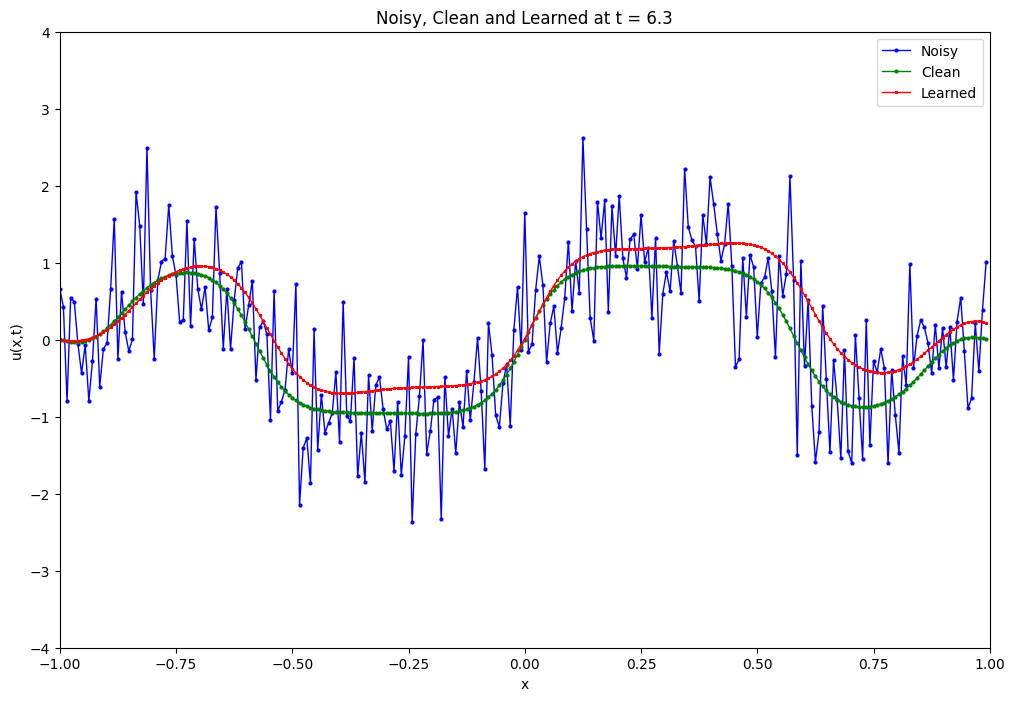

In [10]:
sngl_fig = plt.figure(figsize=(12, 8))

k = rng.choice(a=n_t, size=(1,), replace=False,).item()


plt.plot(x, nsy_vals[k*n_x:(k+1)*n_x:, :], color='blue', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Noisy')
plt.plot(x, cln_vals[k*n_x:(k+1)*n_x:, :], color='green', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Clean')
plt.plot(x, lrn_vals[k*n_x:(k+1)*n_x:, :], color='red', marker='*', linestyle='solid', linewidth=1, markersize=2, label='Learned')
plt.xlabel('x')
plt.xlim(left=x_min, right=x_max)
plt.ylabel('u(x,t)')
plt.ylim(bottom=y_min, top=y_max)
plt.title('Noisy, Clean and Learned at t = {}'.format(t[k].round(dgt)))
plt.legend()

plt.show()

### Now contour like Plots for the Clean, Noisy and Learned Data

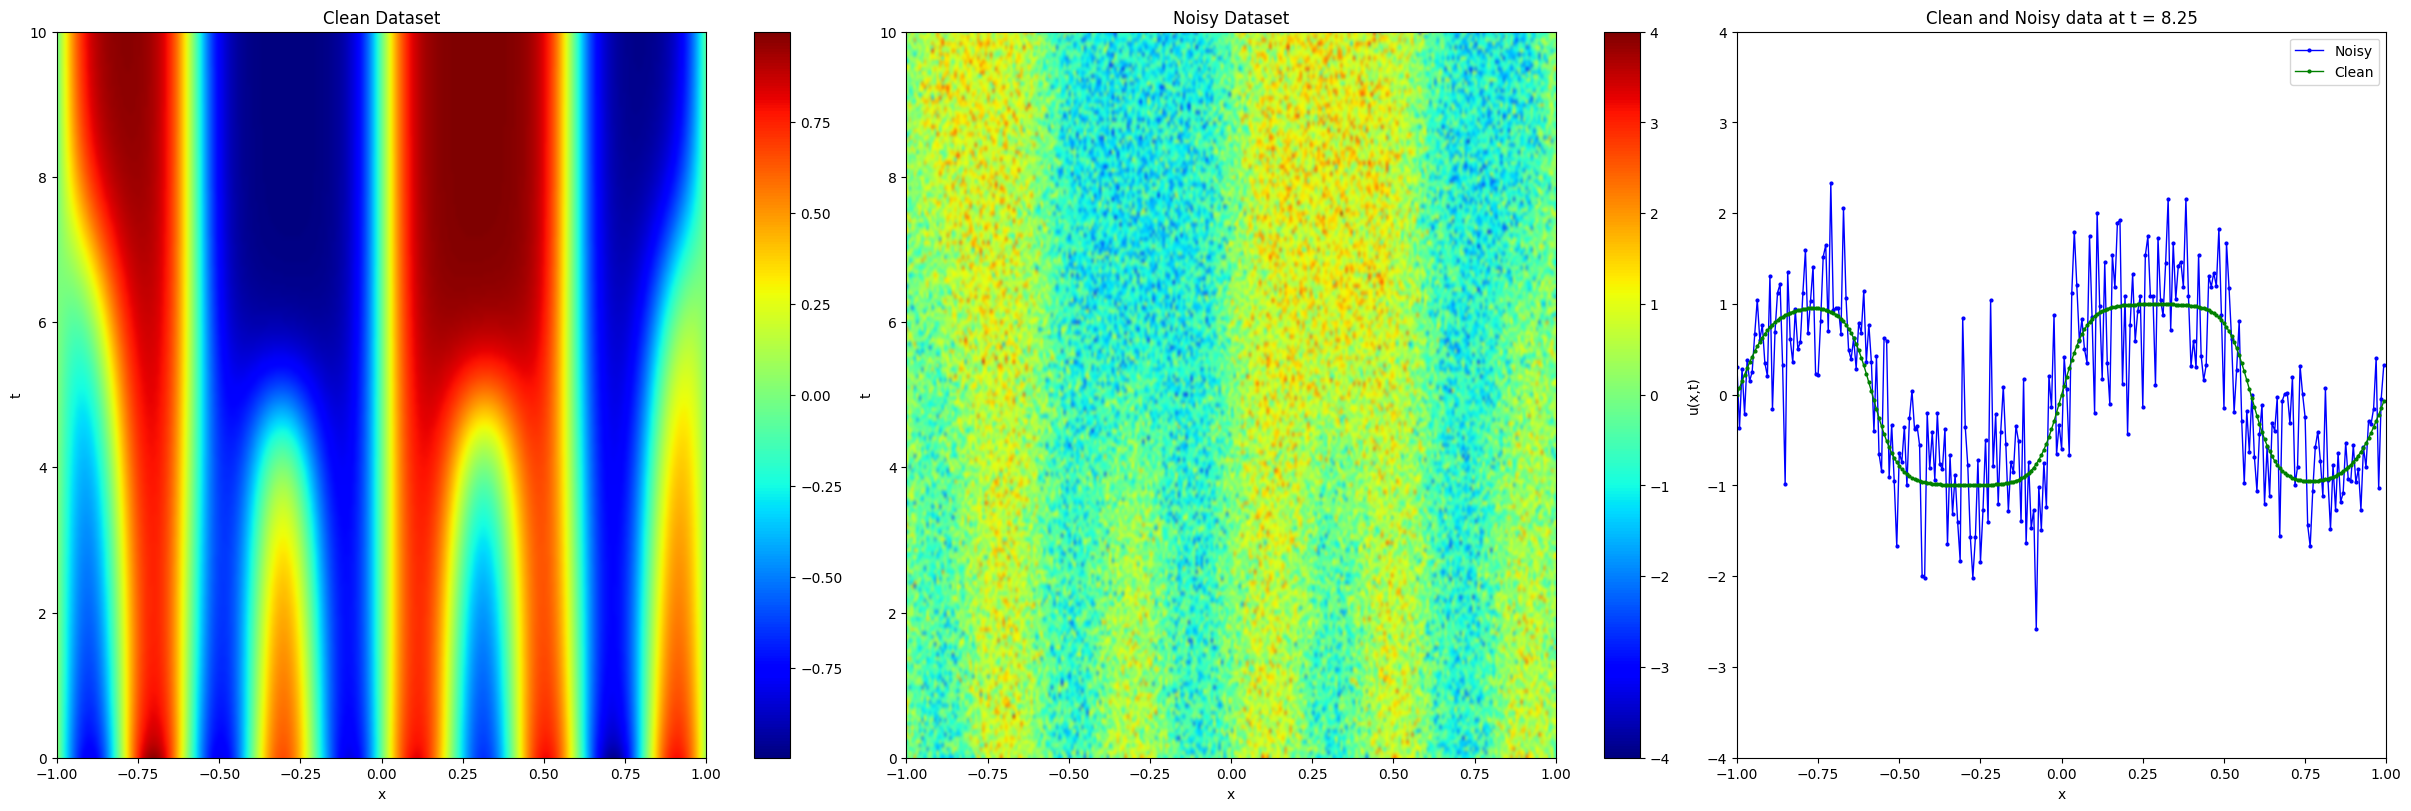

<Figure size 1200x800 with 0 Axes>

In [20]:
cntr_fig, cntr_axes = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, squeeze=True, layout="constrained", figsize=(24,8))

c_map = 'jet'
# c_map = 'seismic'



if cln_vals.min()<0 and cln_vals.max()<=0: norm = Normalize(vmin=cln_vals.min(), vmax=0.0)
elif cln_vals.min()>=0 and cln_vals.max()>0: norm = Normalize(vmin=0.0, vmax=cln_vals.max())
else: norm = TwoSlopeNorm(0.0, cln_vals.min(), cln_vals.max())


c = cntr_axes[0].imshow(cln_vals.reshape((n_t, n_x, )), cmap=c_map, norm=norm,
              extent=[x_min, x_max, t.min(), t.max()],
              interpolation='bicubic', origin='lower', aspect='auto')
cntr_axes[0].set_title('Clean Dataset')
cntr_axes[0].set_xlabel('x')
cntr_axes[0].set_ylabel('t')

cntr_fig.colorbar(c, ax=cntr_axes[0], location='right', orientation='vertical',)

if y_min<0 and y_max<=0: norm = Normalize(vmin=y_min, vmax=0.0)
elif y_min>=0 and y_max>0: norm = Normalize(vmin=0.0, vmax=y_max)
else: norm = TwoSlopeNorm(0.0, y_min, y_max)

c = cntr_axes[1].imshow(nsy_vals.reshape((n_t, n_x, )), cmap=c_map, norm=norm,
              extent=[x_min, x_max, t.min(), t.max()],
              interpolation='bicubic', origin='lower', aspect='auto')
cntr_axes[1].set_title('Noisy Dataset')
cntr_axes[1].set_xlabel('x')
cntr_axes[1].set_ylabel('t')

cntr_fig.colorbar(c, ax=cntr_axes[1], location='right', orientation='vertical',)


sngl_fig = plt.figure(figsize=(12, 8))

k = rng.choice(a=n_t, size=(1,), replace=False,).item()


cntr_axes[2].plot(x, nsy_vals[k*n_x:(k+1)*n_x:, :], color='blue', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Noisy')
cntr_axes[2].plot(x, cln_vals[k*n_x:(k+1)*n_x:, :], color='green', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Clean')
# cntr_axes[2].plot(x, lrn_vals[k*n_x:(k+1)*n_x:, :], color='red', marker='*', linestyle='solid', linewidth=1, markersize=2, label='Learned')
cntr_axes[2].set_xlabel('x')
cntr_axes[2].set_xlim(left=x_min, right=x_max)
cntr_axes[2].set_ylabel('u(x,t)')
cntr_axes[2].set_ylim(bottom=y_min, top=y_max)
cntr_axes[2].set_title('Clean and Noisy data at t = {}'.format(t[k].round(dgt)))
cntr_axes[2].legend()

# plt.show()


# c = cntr_axes[2].imshow(lrn_vals.reshape((n_t, n_x, )), cmap=c_map, norm=norm,
#               extent=[x_min, x_max, t.min(), t.max()],
#               interpolation='bicubic', origin='lower', aspect='auto')
# cntr_axes[2].set_title('Learned Equation')
# cntr_axes[2].set_xlabel('x')
# cntr_axes[2].set_ylabel('t')

# cntr_fig.colorbar(c, ax=cntr_axes[2], location='right', orientation='vertical',);

In [12]:
spdx=1

In [13]:
def learned_animation(i, ax, pts:np.ndarray, nsy:np.ndarray, clean:np.ndarray, lrnd:np.ndarray, maxs:list, mins:list ,t:np.array, dgt:int):
    k = int(i*spdx)
    n_t = t.shape[0]
    n_x = int(pts.shape[0]/n_t)
    x = pts[k*n_x:(k+1)*n_x,0:1]
    # x.sort()
    # lrn = lrnr.net(torch.from_numpy(pts[k*n_x:(k+1)*n_x,:]).to(device=lrnr.device, dtype=lrnr.data_type, non_blocking=True)).cpu().detach().numpy()
    x_min, y_min = mins
    x_max, y_max = maxs
    ax.clear()
    ax.plot(x, nsy[k*n_x:(k+1)*n_x:, :], color='blue', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Noisy Data')
    ax.plot(x, clean[k*n_x:(k+1)*n_x:, :], color='green', marker='o', linestyle='solid', linewidth=1, markersize=2, label='Clean Data')
    ax.plot(x, lrnd[k*n_x:(k+1)*n_x:, :], color='red', marker='*', linestyle='solid', linewidth=1, markersize=2, label='Learned')
    ax.set_xlabel('x')
    ax.set_xlim(left=x_min, right=x_max)
    ax.set_ylabel('u(x,t)')
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.set_title(' Learned Equation/Model at t = {}'.format(t[k].round(dgt)))
    ax.legend()

        

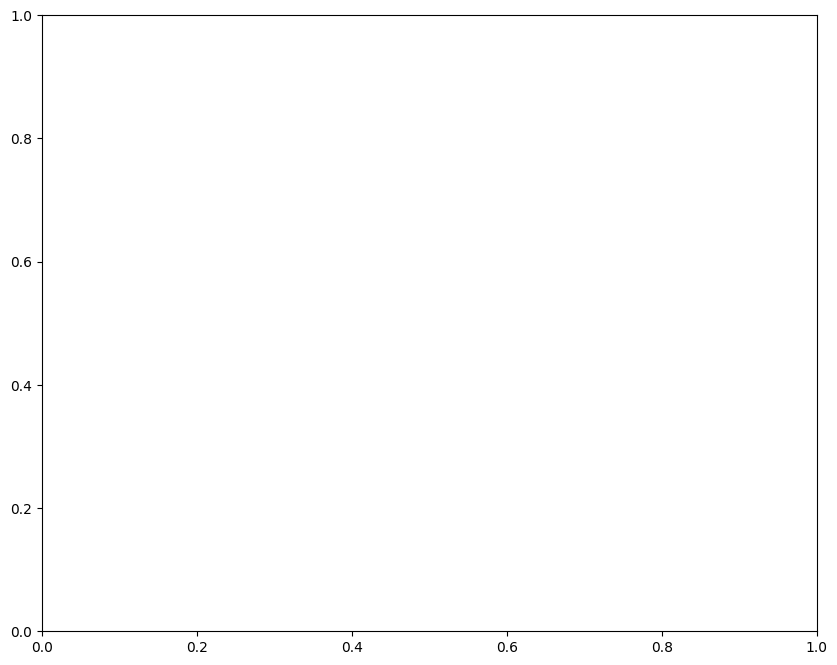

In [14]:
# Something to make sure that we have the prediction and the exact values on the cpu and in numpy arrays for ploting
if isinstance(nsy_vals, torch.Tensor):vals = nsy_vals.cpu().detach().numpy()
elif isinstance(nsy_vals, np.ndarray):vals = np.copy(nsy_vals)
else: raise TypeError(f"The values function argument needs to be either a torch.Tensor or numpy.ndarray object not a {type(nsy_vals).__name__} object as was given!")
if isinstance(cln_vals, torch.Tensor):vals_cln = cln_vals.cpu().detach().numpy()
elif isinstance(cln_vals, np.ndarray):vals_cln = np.copy(cln_vals)
# N by 2 array/tensors these need to be. 
if isinstance(pts, torch.Tensor):X = pts.cpu().detach().numpy()
elif isinstance(pts, np.ndarray): X = np.copy(pts)
else:raise TypeError(f"The pts function argument needs to be either a torch.Tensor or numpy.ndarray object not a {type(pts).__name__} object as was given!")
        
sv_dir = os.path.join('PosterAnimatedPlots', data_set)
os.makedirs(name=sv_dir, exist_ok=True)
    
t = np.unique(X[:, 1])
t.sort()
rnd = int(np.log10(np.min(t[1:]-t[:-1]))) + 3
y_max = np.ceil(vals.max())
y_min = np.floor(vals.min())
x_max, x_min = np.ceil(pts[:, 0].max()), np.floor(pts[:,0].min())
mins = [x_min, y_min]
maxs = [x_max, y_max]
        
plot_fig, ax = plt.subplots()
plot_fig.set_size_inches(w=10, h=8)

In [15]:
t[2]

np.float64(0.1)

In [16]:
ani_plot = animation.FuncAnimation(
    plot_fig, learned_animation, fargs=(ax, X, vals, vals_cln, lrn_vals, maxs, mins, t, rnd), save_count=50, 
    frames=int(t.shape[0]/spdx), interval=100, repeat=True, blit=False)
plot_fig.suptitle(fig_title,fontsize=10);

C:\Users\urzua\AppData\Local\Temp\ipykernel_20440\4016765220.py:1: UserWarning: You passed in an explicit save_count=50 which is being ignored in favor of frames=201.
  ani_plot = animation.FuncAnimation(


In [17]:
writer = animation.FFMpegWriter(fps=30, codec='mpeg4', metadata=dict(artist='Me'), bitrate=-1)
# ani_plot.save(ani_title+'.gif', writer=writer)
# ani_plot.save(os.path.join(sv_dir, 'BestCoefEQ.gif'), writer=writer)

### Now the figues that come from the Sparse Regression

Need to run everything up and through ADO 

In [18]:
run_time = 0
# preAlpha
strt = perf_counter()
lrnr.AdamsOptimTraining(mode="pre", alpha=1.0, gamma=preGamma, min_epochs=min_epchs, max_epochs=max_epchs, 
                        lrn_rt=lrn_rt, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)

Beginning Adams Pre-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.19565e+00 | 1.51929e-02 | 0.0000e+00
            | Test Data  | 1.09240e+00 | 1.66148e-02 | 
Epoch   200 | Train Data | 8.40659e-01 | 7.57586e-04 | 5.5694e-02
            | Test Data  | 8.27931e-01 | 7.77764e-04 | 
Epoch   400 | Train Data | 8.36811e-01 | 6.78035e-04 | 6.2780e-02
            | Test Data  | 8.25054e-01 | 6.84897e-04 | 
Epoch   600 | Train Data | 8.13646e-01 | 1.18021e-03 | 1.3220e-01
            | Test Data  | 8.03085e-01 | 1.24007e-03 | 
Epoch   800 | Train Data | 6.01500e-01 | 7.56032e-03 | 1.4520e-01
            | Test Data  | 6.03513e-01 | 8.91621e-03 | 
Epoch  1000 | Train Data | 5.67159e-01 | 6.87330e-03 | 1.6624e-01
            | Test Data  | 5.73503e-01 | 6.10959e-03 | 
Epoch  1200 | Train Data | 5.51562e-01 | 4.57427e-03 | 1.7350e-01
            | Tes

In [19]:
strt = perf_counter()
lrnr.ADO_Training(iters=ADO_iters, optim_alpha_grwth_methd="poly", LBFGS=False, lbfgs_epochs=10, Early_Term=True, Save_File_Name=None, Early_RFE_Term=True, p=0.5)
# lrnr.ADO_Training(iters=ADO_iters, optim_alpha_grwth_methd="poly", LBFGS=False, lbfgs_epochs=10, Early_Term=False, Save_File_Name=None, Early_RFE_Term=True, p=0.5, train_alphas=ADO_alphas/ADO_alphas)
run_time += (perf_counter() - strt)

lmbda at ADO iter 0 is ...
The current Learned Equation(s) is(are) ... 
u_t = 2.28092770e-01*u + -5.26403000e-03*u_x0x0 + -3.31104400e-02*(u)(u_x0) + -1.06123000e-03*(u_x0)(u_x0x0) + -2.10869770e-01*(u)^3 + 1.26601300e-02*(u)^2(u_x0x0) + -1.15166100e-02*(u)(u_x0)^2 + -2.28900000e-04*(u)(u_x0)(u_x0x0) + 7.35990000e-04*(u)(u_x0x0)^2 + -1.35900000e-05*(u_x0)(u_x0x0)^2 + 1.69100000e-05*(u_x0x0)^3
Beginning Adams ADO-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 5.35858e-01 | 1.73209e-03 | 5.0357e-01
            | Test Data  | 5.38837e-01 | 8.78560e-01 | 
Epoch   100 | Train Data | 5.28391e-01 | 1.74330e-03 | 5.0474e-01
            | Test Data  | 5.34386e-01 | 1.82154e-03 | 
Epoch   200 | Train Data | 5.21207e-01 | 2.05915e-03 | 5.0033e-01
            | Test Data  | 5.27349e-01 | 9.60189e-03 | 
Epoch   300 | Train Data | 5.11728e-01 | 9.97099e-03 

In [20]:
slvr._all_iter_coefs[0]

array([[[ 22.809362 ],
        [  0.       ],
        [-19.257347 ],
        [  0.       ],
        [ -7.525164 ],
        [  0.       ],
        [  0.       ],
        [ -9.780871 ],
        [  0.       ],
        [-12.598469 ],
        [  0.       ],
        [ 20.745636 ],
        [ -9.6401615],
        [ -1.0907313],
        [ 37.472485 ],
        [  0.       ],
        [  0.       ],
        [ -2.7142587],
        [ 32.33479  ]],

       [[ 22.806807 ],
        [  0.       ],
        [-19.300169 ],
        [  0.       ],
        [ -7.580128 ],
        [  0.       ],
        [  0.       ],
        [ -9.844535 ],
        [  0.       ],
        [-12.57997  ],
        [  0.       ],
        [ 20.89996  ],
        [ -9.657123 ],
        [ -1.1312051],
        [ 37.699657 ],
        [  0.       ],
        [  0.       ],
        [ -2.7559988],
        [ 32.45835  ]],

       [[ 22.830872 ],
        [  0.       ],
        [-19.226913 ],
        [  0.       ],
        [ -7.5307903],
       

In [21]:
sprs_coefs = np.zeros(shape=(lrnr._ADO_iters, Kfolds, len(lib_names)))

In [22]:
for mat in slvr._all_iter_coefs: print(mat.shape)

(20, 19, 1)
(20, 11, 1)
(20, 8, 1)
(20, 4, 1)
(20, 2, 1)


In [23]:
# slvr._all_iter_coefs
lrnr._ADO_lambdas[0].nonzero()[0]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18])

In [24]:
for k in range(lrnr._ADO_iters):
    inds = lrnr._ADO_lambdas[k].nonzero()[0]
    tmp_coefs = np.copy(slvr._all_iter_coefs[k].reshape(slvr._all_iter_coefs[k].shape[:-1]))
    for i in range(Kfolds):
        sprs_coefs[k,i, inds] = tmp_coefs[i]

In [25]:
sprs_coefs[1]

array([[ 39.57155228,   0.        , -14.1831789 ,   0.        ,
         -8.12200546,   0.        ,   0.        ,  -8.70178604,
          0.        , -26.09380341,   0.        ,   0.        ,
        -11.95473671,   0.        ,   6.20486975,   0.        ,
          0.        ,   0.        ,  18.41852951],
       [ 39.56327438,   0.        , -14.29728889,   0.        ,
         -8.08854103,   0.        ,   0.        ,  -8.69134998,
          0.        , -26.15605354,   0.        ,   0.        ,
        -11.98415089,   0.        ,   6.37847424,   0.        ,
          0.        ,   0.        ,  18.64662552],
       [ 39.5703392 ,   0.        , -14.30537033,   0.        ,
         -8.08532238,   0.        ,   0.        ,  -8.68167305,
          0.        , -26.1932373 ,   0.        ,   0.        ,
        -11.96393299,   0.        ,   6.40241528,   0.        ,
          0.        ,   0.        ,  18.66648293],
       [ 39.57958984,   0.        , -14.24375725,   0.        ,
         -8.065

In [26]:
lrnr._ADO_lambdas[1].nonzero()[0]
# lrnr._ADO_lambdas[1].shape

array([ 0,  2,  4,  7,  9, 11, 12, 13, 14, 17, 18])

In [27]:
sprs_coefs.shape

(5, 20, 19)

In [28]:
for k in range(lrnr._ADO_iters):
    print(f"Ids for the sparse regression solutions from the {k} iteration")
    for j in range(Kfolds):
        ids = sprs_coefs[k,j,:].nonzero()[0]
        print(ids)


Ids for the sparse regression solutions from the 0 iteration
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
[ 0  2  4  7  9 11 12 13 14 17 18]
Ids for the sparse regression solutions from the 1 iteration
[ 0  2  4  7  9 12 14 18]
[ 0  2  4  7  9 12 14 18]
[ 0  2  4  7  9 12 14 18]
[ 0  2  4  7  9 12 14 18]
[ 0  2  4  7  9 12 14 18]
[ 0  2  4  7  9 12 14 18]
[ 0  2  4  7  9 12 14 

In [29]:
ADO_LmbdaIDs = [0] + [0] * (lrnr._ADO_iters-1)

In [30]:
from matplotlib import cm
from matplotlib.patches import Rectangle, Polygon

In [31]:
def ADO_RHS_Eqs(iter_coefs:np.ndarray, library_names:list[str],
                dset_name:str, cmap_name:str, fig_title:str, save_fig:bool=True)->None:
    """
    TODO:   (1) Descriptive Text Goes here dumbass
            (2) Input args checking as usual dumb ass
            (3) Probably the most important thing is to redo this function so that figure size
                remains the same (constant) but that the "table" entries sizes expand and 
                compress when there are more entries to be had the table because at this moment
                a figure size can be set to size that catorch.nnnot be created/saved as there would 
                be too many pixels (Have gotten the following error message - Image size of 
                2926x92322 pixels is too large. It must be less than 2^16 in each direction.)
    """
    sv_dir = os.path.join("AdoPDEs", dset_name)
    os.makedirs(sv_dir, exist_ok=True)
    # Note that z_m := # of library funcs, z_n := # of batches,  iters := # ADO iterations
    iters, z_n , z_m = iter_coefs.shape
    # should double check that iters equals self._ADO_iters for safety

    cmp = plt.get_cmap(cmap_name)
    norm = plt.Normalize(0, z_n)
    scalarMap = cm.ScalarMappable(norm=norm, cmap=cmp)
    # Since we do not know ahead of time the forms of RHS that were considered need to used lists and append things with a first pass through
    ADO_LmbdaIDs = []
    RHSs1 = [[] for _ in range(iters)]
    cell_clrs1 = [[] for _ in range(iters)]
    counts1 = [[] for _ in range(iters)]
    N_l1 = [[] for _ in range(iters)]
    non_zs = np.linspace(0, z_m-1, z_m, dtype=int)
    # subscript for the coefficients in the library
    subscript = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    for l in range(iters):
        # get all the lambds from the the batches for the l-th iteration of ADO
        all_lambdas = iter_coefs[l]
        # now just restrict to the nonzeros components of the batched lambdas
        reduced_lambds = all_lambdas[:, non_zs]
        # now get the number of components that we restricted ourself to
        m = non_zs.shape[0]
        # now there are 2^m combinations the m functions so need to determine of all these how much of each of them was selected 
        counts = np.zeros(shape=(z_n,), dtype=int) 
        # can identify each of the 2^m combinations using a binary representation of sorts i.e 101001 means 
        # RHS:= c_{0}f_{0} + c_{2}f_{2} + c_{5}f_{5} assuming m=5 and is the 1*2^0 + 1*2^2 + 1*2^5 = 37th combination of the m funcs
        libSlcts = np.where(reduced_lambds==0, 0,1)
        for j in range(z_n):
            c = np.all(libSlcts[j,:]==libSlcts,axis=1).sum()
            if np.any(np.all(libSlcts[j,:]==libSlcts[:j,:],axis=1)):
                continue
            else:
                counts[j] = c
        # Now lets get the binary represenation for each of the z_n combinations of the m funcs stored row wise
        for j in range(z_n):
            if counts[j]==0: 
                continue
            rhs = ''
            for i in range(z_m):
                if libSlcts[j, i]==0: 
                    continue
                coef = 'c'+str(non_zs[i])
                if non_zs[i]==0 and library_names[0]=='1': 
                    rhs = rhs + coef.translate(subscript) +' + '
                else: 
                    rhs = rhs + coef.translate(subscript) + library_names[non_zs[i]] +' + '
            rhs = rhs[:-3]
            ind = 0
            num_lines = 1
            while len(rhs[ind:])>=30:
                ind = rhs[ind:ind+30].rfind('+') + ind
                rhs = rhs[:ind]+'\n'+rhs[ind:]
                num_lines+=1
            RHSs1[l].append(rhs)
            cell_clrs1[l].append(scalarMap.to_rgba(counts[j]))
            counts1[l].append(counts[j])
            N_l1[l].append(num_lines+1)
        ADO_LmbdaIDs.append(np.argmax(counts).item())
    chosen = []
    for j, idx in enumerate(ADO_LmbdaIDs):
        rhs = ''   # form the right hand side equation of the selected functions via concatenation
        for k in range(z_m):
            # if the i-th function was not selected for this fold skip it in forming the rhs
            if iter_coefs[j, idx, k]==0: 
                continue
            # coefficient that goes in front of the selected lib. func. 
            coef = 'c'+str(non_zs[k]) 
            if non_zs[k]==0 and library_names[0]=='1': 
                # if the very first (0-th) function in the library is the constant 1 function
                # and the product of it with a constant (coef) is always the coefficient. 
                rhs = rhs + coef.translate(subscript) +' + '
            else: 
                rhs = rhs + coef.translate(subscript) + library_names[non_zs[k]] +' + '
        rhs = rhs[:-3]  # get rid of the extra/ending ' + '
        ind = 0
        num_lines = 1
        # if the rhs is longer thaan 30 characters make a new line for every 30 characters
        while len(rhs[ind:])>=30:
            ind = rhs[ind:ind+30].rfind('+') + ind
            rhs = rhs[:ind]+'\n'+rhs[ind:]
            num_lines+=1
        chosen.append(RHSs1[j].index(rhs))
    # now that all the RHS forms, the number of times they appeared, the number lines to display the RHS Eqs
    # and colors for the rectanges for each RHS according the color map, place these things in array like 2D lists
    # that are easier to manage (also a bit of a hold over when trying to use the matplotlib.pyplot.table method)
    lengths = np.zeros(shape=(iters,), dtype=int)
    for i in range(iters):
        lengths[i] = len(RHSs1[i])
    tbl_rows = lengths.max()
    RHSs = []
    cell_clrs = []
    counts2 = []
    N_l2 = []
    for i in range(tbl_rows):
        RHSs.append([])
        cell_clrs.append([])
        counts2.append([])
        N_l2.append([])
    for i in range(iters):
        for j in range(tbl_rows):
            if j<len(RHSs1[i]):
                RHSs[j].append(RHSs1[i][j])
                cell_clrs[j].append(cell_clrs1[i][j])
                counts2[j].append(counts1[i][j])
                N_l2[j].append(N_l1[i][j])
            else:
                RHSs[j].append('')
                cell_clrs[j].append((0,0,0,0))
                counts2[j].append(0)
                N_l2[j].append(0)
    # Convert the lists with integer values into numpy arrays
    N_l = np.array(N_l2, dtype=int)
    counts = np.array(counts2, dtype=int)
    # Now lets define the height and width of the rects, the horizontal and verical space between the rects
    # also the figure's width and height in inches
    h_r = (1/3)*N_l.max()
    w_r = 0.5 if iters<=3 else 0.75
    s_h = 0.1
    s_v = 0.25
    m, n = counts.shape
    if m>10:
        m=10
        bst10 = np.empty((10,n), dtype=np.int32)
        for i in range(n):
            bst10[:,i] = np.argsort(counts[:,i],axis=0)[-10:]
            bst10[:,i].sort()
    else:
        bst10 = np.empty((m,n), dtype=np.int32)
        for i in range(n):
            bst10[:,i] = np.linspace(0,m-1, m, dtype=np.int32)
    fig_h = (12/23.77)*(h_r+s_v)*(m)
    fig_w = (24/4.1)*((w_r+s_h)*(iters-1)+w_r)
    # Now make the table like thing in the axis with the rectangles 
    fig, ax = plt.subplots(1, 1, sharex=True, sharey=True,layout='constrained')
    fig.set_size_inches(fig_w, fig_h)
    # ys arrays contains the lower left corner points for all the rectangles to display them from top of the table downward
    ys = np.linspace((m-1)*(h_r+s_v), 0, m)
    for j in range(n):
        i=0
        while counts[bst10[i,j],j]!=0:
            x = j*(w_r+s_h)
            y = i*(h_r+s_v)
            y = ys[i]
            rect = Rectangle((x,y), width=w_r, height=h_r, color=scalarMap.to_rgba(counts[bst10[i,j],j]))
            ax.add_patch(rect)
            # Add the text for the RHS onto the rectangle to but it is was the RHS that was chosen circle it
            if bst10[i,j]==chosen[j]:
                if counts[bst10[i,j],j] > int(z_n/2):
                    ax.text(x+w_r/2, y + h_r/2, RHSs[bst10[i,j]][j], fontsize=10, color='white', rotation='horizontal', horizontalalignment='center', verticalalignment='center',
                    bbox=dict(boxstyle="ellipse,pad=0.4",fc=(0,0,0,0),ec="black"))
                else:
                    ax.text(x+w_r/2, y + h_r/2, RHSs[bst10[i,j]][j], fontsize=10, color='black', rotation='horizontal', horizontalalignment='center', verticalalignment='center',
                    bbox=dict(boxstyle="ellipse,pad=0.4",fc=(0,0,0,0),ec="black"))
            else:
                if counts[bst10[i,j],j] > int(z_n/2):
                    ax.text(x+w_r/2, y + h_r/2, RHSs[bst10[i,j]][j], fontsize=10, color='white', rotation='horizontal', horizontalalignment='center', verticalalignment='center',)
                else:
                    ax.text(x+w_r/2, y + h_r/2, RHSs[bst10[i,j]][j], fontsize=10, color='black', rotation='horizontal', horizontalalignment='center', verticalalignment='center',)
            ax.text(x+w_r, y+h_r, str(counts[bst10[i,j],j]), fontsize=10, color='green', rotation='horizontal', horizontalalignment='right', verticalalignment='top',)
            i+=1
            if i==m: break
    xlabels = ['ADO '+str(l) for l in range(iters)]
    ax.set_xlim(0, (w_r+s_h)*(iters)-s_h)
    ax.set_xticks(ticks=np.linspace(w_r/2, (w_r+s_h)*(iters-1)+w_r/2, iters), labels=xlabels, fontsize=12)
    ax.set_ylim(0.0, (m)*(h_r+s_v))
    ax.set_yticks([])
    if z_n>42:
        tcks = np.linspace(0, z_n, 42,True, dtype=int)
        # tcks = np.linspace(0, z_n, 42,True).round()
    else: tcks = np.linspace(0, z_n, z_n+1,True, dtype=int)
    # ax.set_title('Evolotion of Considered PDE RHS Equations Throughout ADO Training - 10 Most Frequent', fontsize=18)
    ax.set_title('Evolotion of RHS Equations - 10 Most Frequent', fontsize=18)
    clr_tst = fig.colorbar(scalarMap, ax=ax, location='right', orientation='vertical', ticks=tcks)
    clr_tst.ax.set_title('occurrence')
    if save_fig:
        fig.savefig(fname=os.path.join(sv_dir, fig_title+'.png'), format='png')


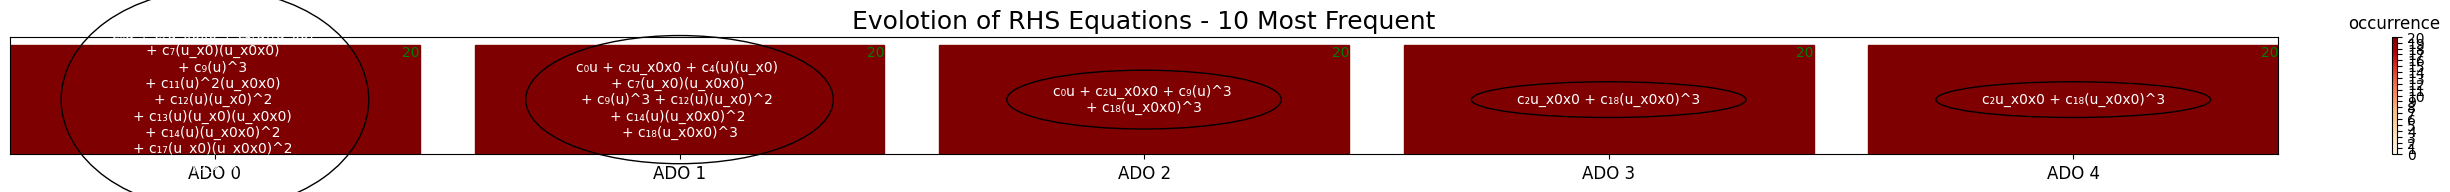

In [32]:
# ADO_RHS_Eqs(iter_coefs=sprs_coefs, library_names=lib_names, ADO_LmbdaIDs=ADO_LmbdaIDs,
                # dset_name=data_set, cmap_name='OrRd', fig_title='AllenCahnVerExample', save_fig=False)
ADO_RHS_Eqs(iter_coefs=sprs_coefs, library_names=lib_names,
                dset_name=data_set, cmap_name='OrRd', fig_title='AllenCahnVerExample', save_fig=False)

In [33]:
lrnr.Learned_EQ(output=True,);

The current Learned Equation(s) is(are) ... 
u_t = -3.09017000e-03*u_x0x0 


In [34]:
def ADO_LibFuncPopEvol(iter_coefs:np.ndarray, library_names:list[str], ADO_lambdas:list[np.ndarray],
                dset_name:str, cmap_name:str, delta:float, fig_title:str, save_fig:bool=True):
    
    sv_dir = os.path.join("AdoLibPopEvol", dset_name)
    os.makedirs(sv_dir, exist_ok=True)
    # Note that z_m := # of library funcs, z_n := # of batches, iters := # ADO iterations
    iters, z_n , z_m = iter_coefs.shape
    # should double check that iters equals self._ADO_iters for safety

    cmp = plt.get_cmap(cmap_name)
    norm = plt.Normalize(0, z_n)
    scalarMap = cm.ScalarMappable(norm=norm, cmap=cmp)
    fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, layout='constrained')
    fig.set_size_inches(z_m*1.25,(12/7)*iters)
    fig.set_size_inches(18,7)
    ax.set_facecolor("white")
    non_zs = ADO_lambdas[0].nonzero()[0]   # generally this is just [0, 1,..., n-1] since at the start of ADO every things should be nonzero
    counts = np.empty(shape=(iters, non_zs.shape[0]), dtype=int)
    sorted_cnts = np.empty(shape=(iters, non_zs.shape[0]), dtype=int)
    for l in range(iters):
        btch = np.copy(iter_coefs[l])
        counts[l] = np.count_nonzero(btch[:, non_zs], axis=0)
        sorted_cnts[l] = np.flip(np.argsort(counts[l]))
    # s = int(z_m/np.count_nonzero(counts[0]))
    # e = z_m/np.count_nonzero(counts[0]) - s
    # ys = np.linspace(np.count_nonzero(counts[0])-1, 0, np.count_nonzero(counts[0]))*(s+e)
    s = 1
    e = 0.333
    ys = np.linspace(z_m-1, 0, z_m)*(s+e)
    xs = np.linspace(0, iters, iters+1)*(1+delta)
    indices = np.empty(shape=(iters,),dtype=int)

    for l in range(iters):    
        i = 0
        for j in sorted_cnts[l]:
            if counts[l,j]==0: continue
            x = xs[l]
            y = ys[i]
            r_c, g_c, b_c, a_c = scalarMap.to_rgba(counts[l,j])
            # rect = Rectangle((x,y), width=1, height=s, color=scalarMap.to_rgba(counts[l,j]))
            rect = Rectangle((x,y), width=1, height=s, color=(r_c, g_c, b_c, a_c))
            # rect = Rectangle((x,y), width=1, height=s)
            ax.add_patch(rect)
            mid = y + s/2
            if counts[l,j]<=int(z_n/2):
                ax.text(x+0.5, mid, library_names[j], fontsize=10, color='black', rotation='horizontal', horizontalalignment='center', verticalalignment='center',)
            else:
                ax.text(x+0.5, mid, library_names[j], fontsize=10, color='white', rotation='horizontal', horizontalalignment='center', verticalalignment='center',)
            # ax.text(x+0.5, mid, library_names[j], fontsize=10, color=((counts[l,j]-1)/(z_n-1),(counts[l,j]-1)/(z_n-1),(counts[l,j]-1)/(z_n-1),1), rotation='horizontal', horizontalalignment='center', verticalalignment='center',)
            # ax.hlines(y=[y, y+s], xmin=x ,xmax=x+1, color='black')
            # x.hlines(y=[y, y+s], xmin=x ,xmax=x+1, color='white')
            pre_i = np.argwhere(sorted_cnts[l-1,:]==j).flatten()[0]
            pre_j = sorted_cnts[l-1,pre_i]
            # Now draw the line/rectangle to the previous ADO iteration columns to cotorch.nnect the things
            if l>0 and counts[l-1,pre_j]!=0:
                # pre_i = np.argwhere(sorted_cnts[l-1,:]==j).flatten()[0]
                # pre_j = sorted_cnts[l-1,pre_i]
                pre_x = x-delta
                pre_y = ys[pre_i]
                tst_xy = np.array([[x,y], [x,y+s], [pre_x, pre_y+s], [pre_x, pre_y]])
                r_p, g_p, b_p, a_p = scalarMap.to_rgba(counts[l-1,pre_j])
                # poly = Polygon(xy=tst_xy, closed=True, facecolor=((r_c+r_p)/2, (g_c+g_p)/2, (b_c+b_p)/2, (a_c+a_p)/2), edgecolor='black')
                # poly = Polygon(xy=tst_xy, closed=True, facecolor=((r_c+r_p)/2, (g_c+g_p)/2, (b_c+b_p)/2, (a_c+a_p)/2), edgecolor='white')
                # poly = Polygon(xy=tst_xy, closed=True, color=((r_c+r_p)/2, (g_c+g_p)/2, (b_c+b_p)/2, (a_c+a_p)/2),) # colour of the cotorch.nnecting reactangle is average of the current and previous ADO colours
                # poly = Polygon(xy=tst_xy, closed=True, color=(r_c, g_c, b_c, a_c),)         # colour of the cotorch.nnecting reactangle is colour current ADO rectangle
                poly = Polygon(xy=tst_xy, closed=True, color=(r_p, g_p, b_p, a_p),)         # colour of the cotorch.nnecting reactangle is colour previous ADO rectangle
                # ax.plot([pre_x, x], [pre_y, y], 'k-')
                # ax.plot([pre_x, x], [pre_y+s, y+s], 'k-')
                ax.add_patch(poly)
            i+=1
        indices[l] = i-1

    xlabels = ['ADO '+str(l) for l in range(iters)]
    # ax.vlines(x=xs[:-1], ymin=0, ymax=z_m, color='black')
    # ax.vlines(x=xs[:-1]+1, ymin=0, ymax=z_m, color='black')
    ax.set_xlim(0, np.max(xs[:-1]+1))
    ax.set_xticks(ticks=(2*xs[:-1]+1)/2, labels=xlabels, fontsize=12)
    # ax.set_ylim(0, z_m)
    ax.set_ylim(ys[indices.max()], ys[0]+s)
    ax.set_yticks([])
    # ax.set_yticks(ticks=ys+s/2, labels=[])
    if z_n>42:
        # tcks = np.linspace(0, z_n, 42,True, dtype=int)
        tcks = np.linspace(0, z_n, 42,True).round()
    else: tcks = np.linspace(0, z_n, z_n+1,True, dtype=int)
    ax.set_title('Evolution of Library of Candidate Functions Popularity Throughout ADO Training/Learning', fontsize=16)
    clr_tst = fig.colorbar(scalarMap, ax=ax, location='right', orientation='vertical', ticks=tcks)
    clr_tst.ax.set_title('occurrence.')
    # NOTE: Maybe move and change direc
    if save_fig:
        fig.savefig(fname=os.path.join(sv_dir, fig_title+'.png'), format='png')

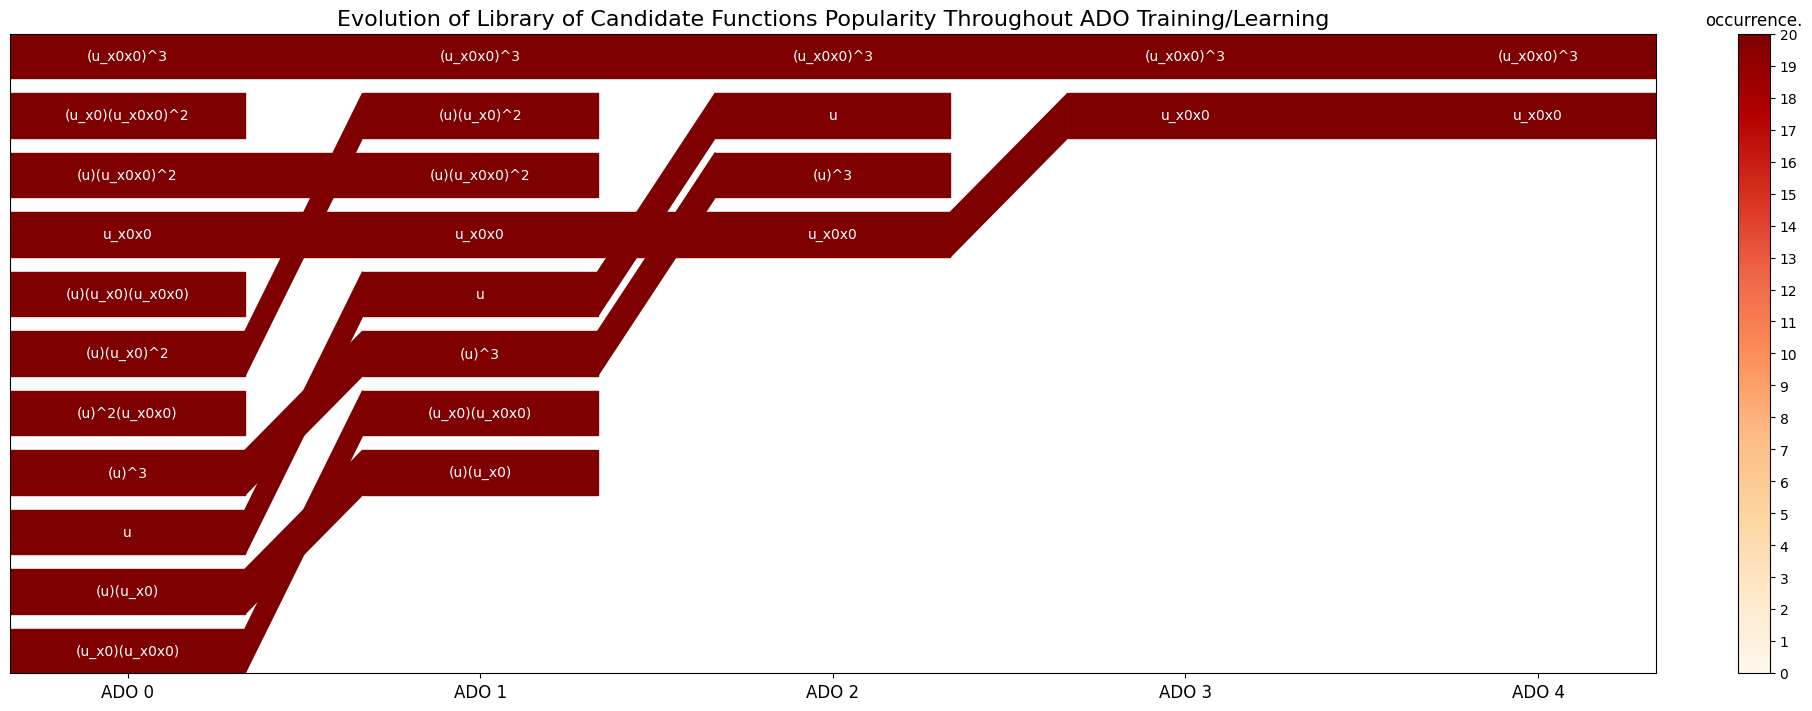

In [35]:
ADO_LibFuncPopEvol(iter_coefs=sprs_coefs, library_names=lib_names, ADO_lambdas=lrnr._ADO_lambdas,
                dset_name=data_set, cmap_name='OrRd', delta=0.5, fig_title='AllenCahnVerExample', save_fig=False)